# Stock Market EDA
Exploratory Data Analysis for AAPL, MSFT, GOOGL, AMZN, NVDA.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data.ingestion import load_config, fetch_multiple_tickers, compute_returns
from src.features.engineering import build_feature_matrix, adf_test
from src.visualization.plots import (
    plot_price_history, plot_returns_distribution, plot_correlation_heatmap,
    plot_technical_indicators, plotly_candlestick
)

config = load_config('../config/config.yaml')
%matplotlib inline

## 1. Data Ingestion

In [2]:
tickers = config['data']['tickers']
raw_data = fetch_multiple_tickers(
    tickers,
    config['data']['start_date'],
    config['data']['end_date'],
    data_dir='../data'
)

# Add returns
data = {t: compute_returns(df) for t, df in raw_data.items()}

ticker = 'AAPL'
df = data[ticker]
print(f'Shape: {df.shape}')
df.head()

Shape: (1760, 8)


,close,high,low,open,volume,daily_return,log_return,cumulative_return
date,,,,,,,,
2018-01-02,40.267082,40.276435,39.565809,39.776193,102223600,NaN,NaN,NaN
2018-01-03,40.260059,40.802379,40.196947,40.330187,118071600,-0.000174,-0.000174,-0.000174
2018-01-04,40.447079,40.549933,40.225010,40.332536,89738400,0.004645,0.004635,0.004470
2018-01-05,40.907570,40.994059,40.451743,40.542909,94640000,0.011385,0.011321,0.015906
2018-01-08,40.755630,41.050164,40.657449,40.755630,82271200,-0.003714,-0.003721,0.012133


## 2. Price & Volume History

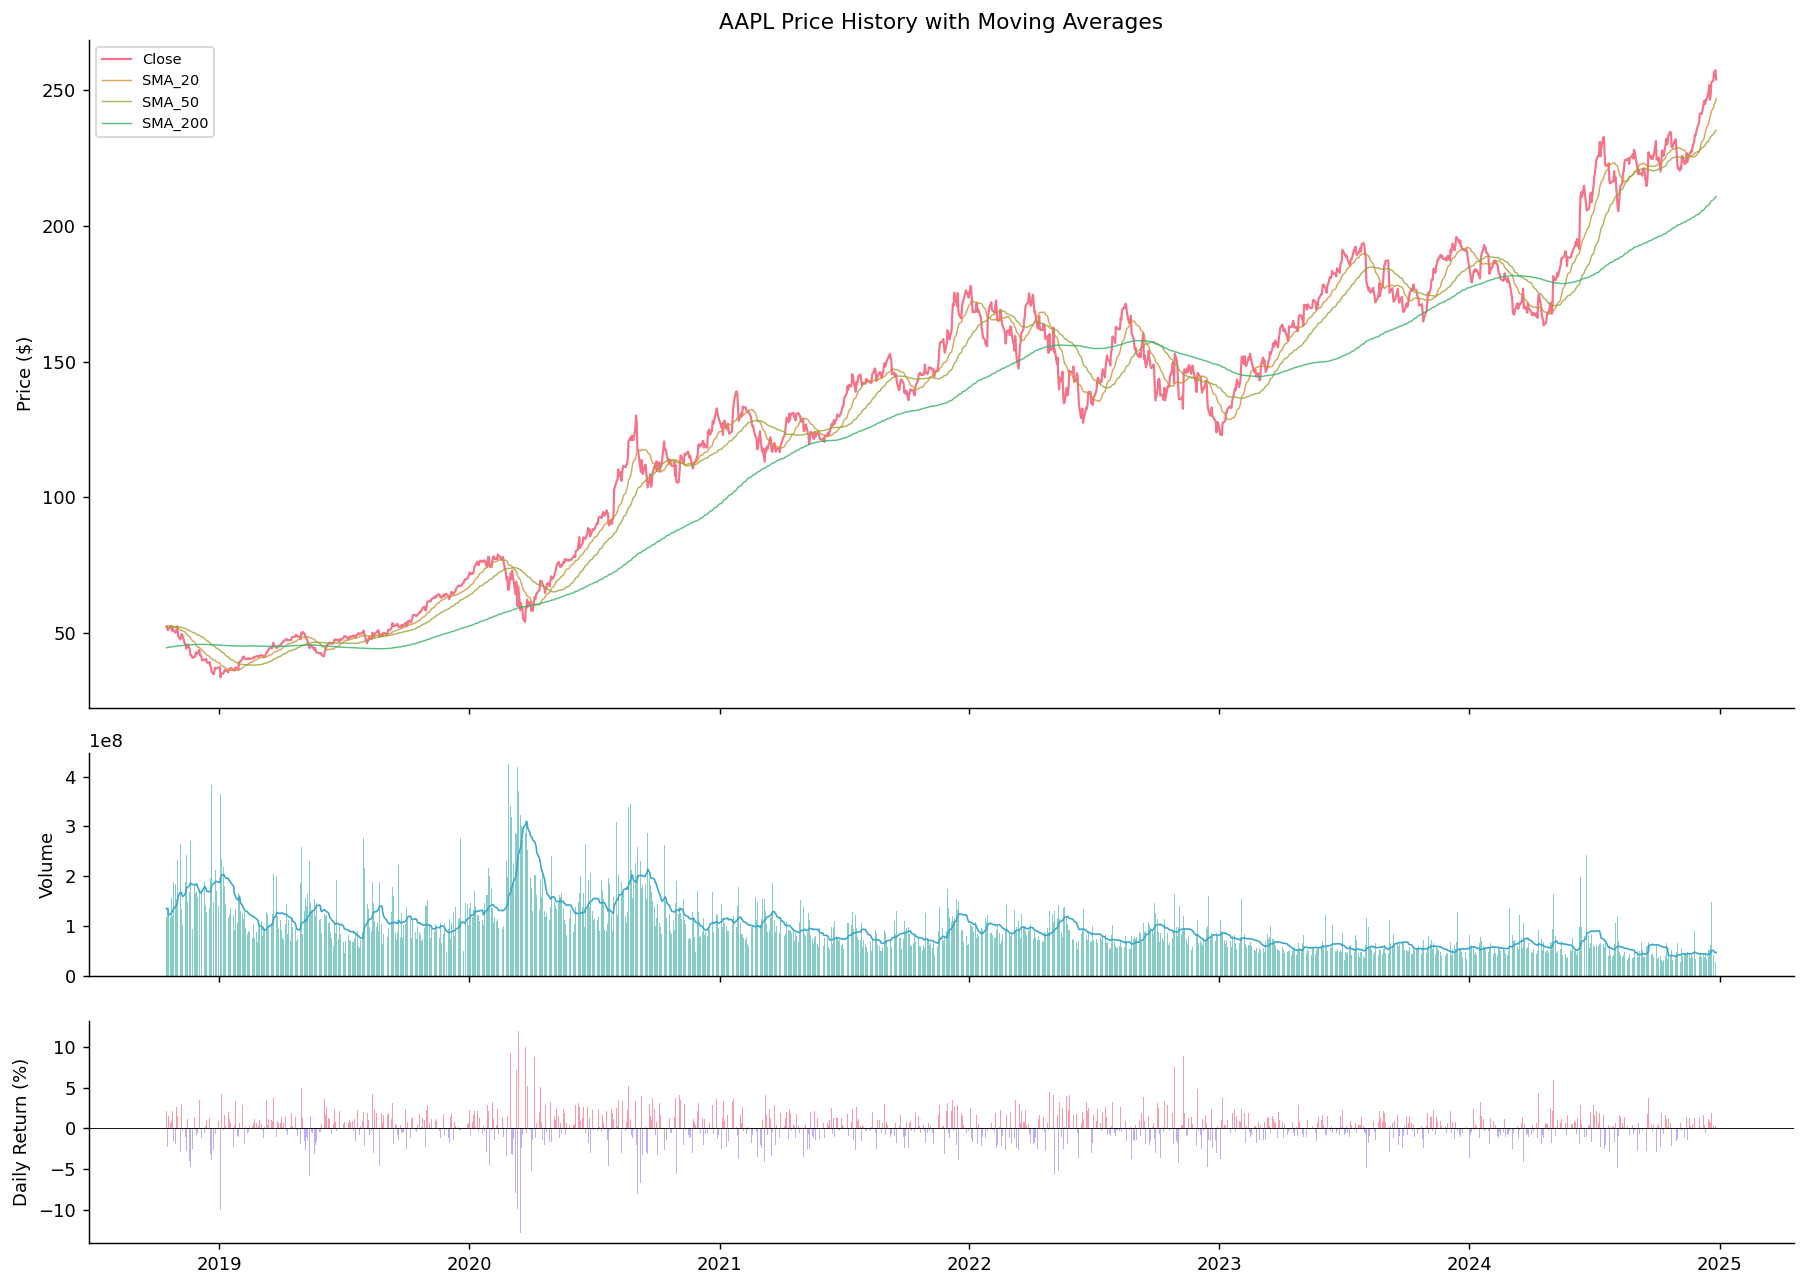

In [3]:
df_feat = build_feature_matrix(df.copy(), config)
fig = plot_price_history(df_feat, ticker=ticker)
plt.savefig('../plots/price_history.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Returns Distribution & Volatility

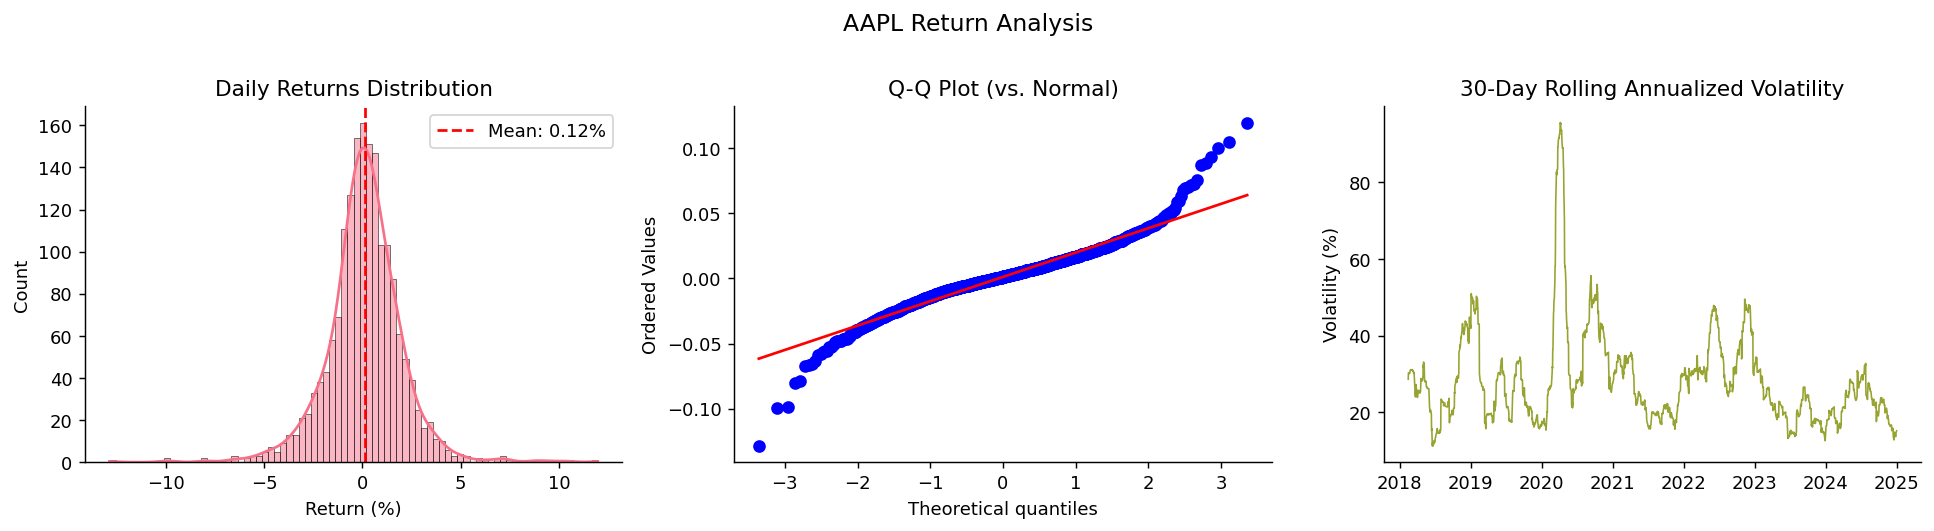

Mean daily return : 0.123%
Std  daily return : 1.925%
Skewness          : -0.0091
Kurtosis (excess) : 5.1220
Annualised vol    : 30.55%


In [4]:
fig = plot_returns_distribution(df, ticker=ticker)
plt.savefig('../plots/returns_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

returns = df['daily_return'].dropna()
print(f'Mean daily return : {returns.mean()*100:.3f}%')
print(f'Std  daily return : {returns.std()*100:.3f}%')
print(f'Skewness          : {returns.skew():.4f}')
print(f'Kurtosis (excess) : {returns.kurtosis():.4f}')
print(f'Annualised vol    : {returns.std()*np.sqrt(252)*100:.2f}%')

## 4. Multi-ticker Correlation

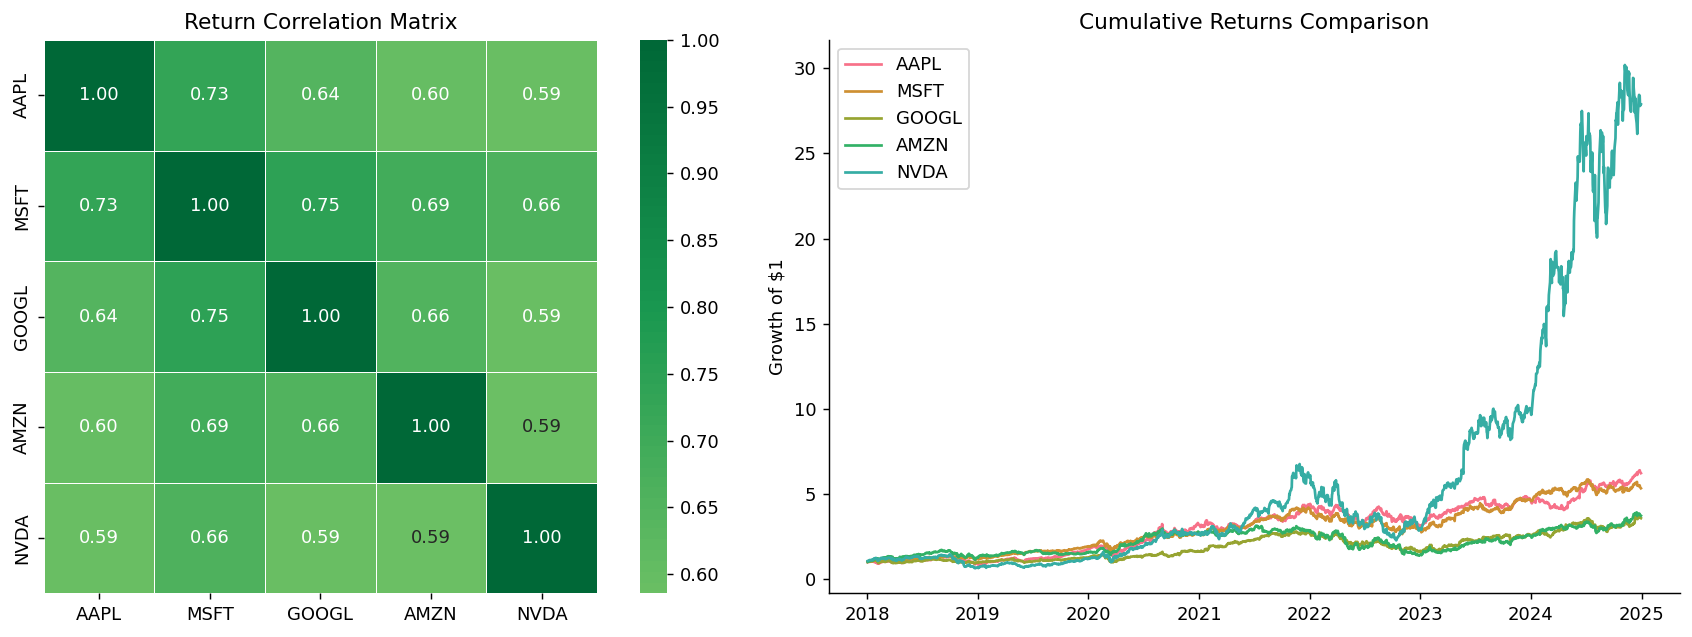

In [5]:
fig = plot_correlation_heatmap(data)
plt.savefig('../plots/correlation.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Technical Indicators

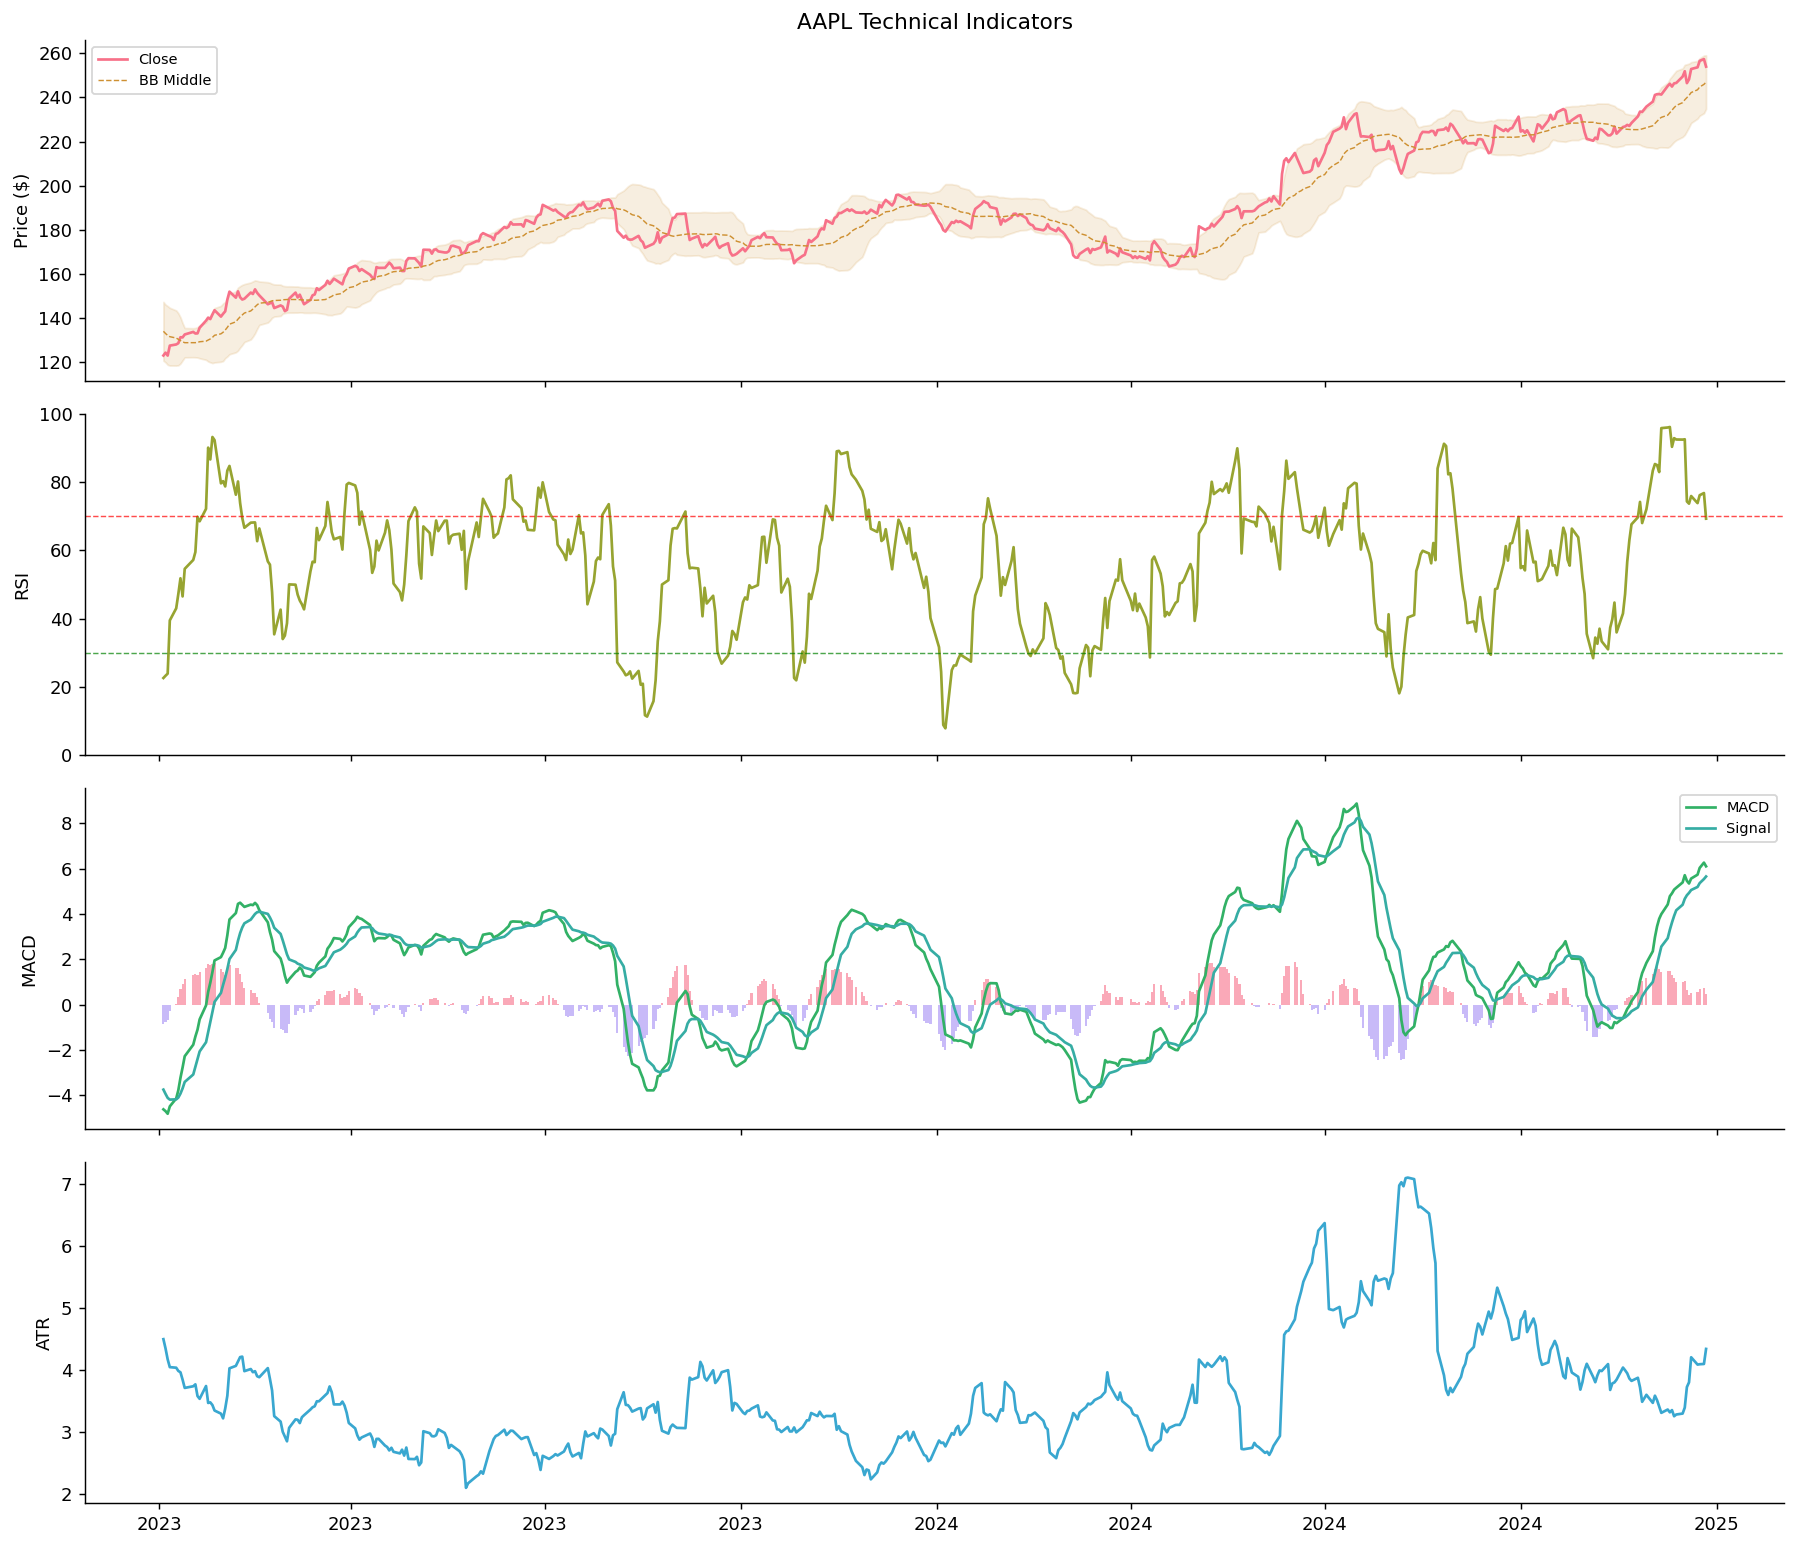

In [6]:
fig = plot_technical_indicators(df_feat.tail(500), ticker=ticker)
plt.savefig('../plots/technical_indicators.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Stationarity Test (ADF)

In [7]:
print('=== ADF Test: Close Price ===')
result = adf_test(df['close'])
for k, v in result.items():
    print(f'  {k}: {v}')

print('\n=== ADF Test: Log Returns ===')
result2 = adf_test(df['log_return'].dropna())
for k, v in result2.items():
    print(f'  {k}: {v}')

=== ADF Test: Close Price ===
  adf_statistic: 0.08300221142390832
  p_value: 0.9648812307913187
  n_lags: 0
  n_obs: 1759
  critical_values: {'1%': np.float64(-3.4340730634421153), '5%': np.float64(-2.8631845252929495), '10%': np.float64(-2.5676454956964605)}
  is_stationary: False

=== ADF Test: Log Returns ===
  adf_statistic: -13.147883269422797
  p_value: 1.3862109638540328e-24
  n_lags: 8
  n_obs: 1750
  critical_values: {'1%': np.float64(-3.4340922388213175), '5%': np.float64(-2.863192990001633), '10%': np.float64(-2.5676500029387754)}
  is_stationary: True


## 7. Interactive Candlestick Chart (Plotly)

In [8]:
fig_plotly = plotly_candlestick(df_feat.tail(365), ticker=ticker)
fig_plotly.show()

## 8. Descriptive Statistics Summary

In [9]:
summary = {}
for t, d in data.items():
    r = d['daily_return'].dropna()
    summary[t] = {
        'Mean Return (%)': round(r.mean() * 100, 3),
        'Std (%)': round(r.std() * 100, 3),
        'Ann. Vol (%)': round(r.std() * np.sqrt(252) * 100, 2),
        'Sharpe (approx)': round(r.mean() / r.std() * np.sqrt(252), 3),
        'Max Drawdown (%)': round(
            ((d['close'] / d['close'].cummax()) - 1).min() * 100, 2
        ),
        'Skewness': round(r.skew(), 4),
    }
pd.DataFrame(summary).T

,Mean Return (%),Std (%),Ann. Vol (%),Sharpe (approx),Max Drawdown (%),Skewness
AAPL,0.123,1.925,30.55,1.010,-38.52,-0.0091
MSFT,0.112,1.820,28.89,0.975,-37.15,-0.0231
GOOGL,0.091,1.940,30.79,0.747,-44.32,-0.0640
AMZN,0.098,2.168,34.42,0.719,-56.15,0.0326
NVDA,0.242,3.247,51.54,1.183,-66.34,0.1595
